# Dataset Exploration Notebook

## Hugging Face Isolated-guitar-chords

### Explore Decoder Format

In [119]:
import sys
print(sys.executable)

/Users/thomascanro/Desktop/CLASSES/CPEDesign/ChordSenseDisplay/venv/bin/python


In [121]:
import torch
import torchcodec
from datasets import load_dataset, Audio

ds = load_dataset("rodriler/isolated-guitar-chords")

In [123]:
## Try Resampling:
ds = ds.cast_column("audio", Audio(sampling_rate=22050))

In [125]:
sample = ds["train"][1]
print(sample.keys())

dict_keys(['audio', 'label'])


In [127]:
print(type(ds["train"]))

<class 'datasets.arrow_dataset.Dataset'>


In [129]:
print(sample)

{'audio': <datasets.features._torchcodec.AudioDecoder object at 0x17e46fb30>, 'label': 1}


In [131]:
audio = sample["audio"]
print(type(audio))
print(sample["label"])
all_samples = audio.get_all_samples()
print(all_samples.sample_rate)

<class 'datasets.features._torchcodec.AudioDecoder'>
1
22050


In [133]:
waveform = sample["audio"].get_all_samples()

x = waveform.data          # tensor
sr = waveform.sample_rate  # int

print(x.shape)
print(sr)

torch.Size([1, 126720])
22050


In [139]:
labels = ds["train"].features["label"].names
print(labels)

['A', 'A#', 'A#m', 'Am', 'B', 'Bm', 'C', 'C#', 'C#m', 'Cm', 'D', 'D#', 'D#m', 'Dm', 'E', 'Em', 'F', 'F#', 'F#m', 'Fm', 'G', 'G#', 'G#m', 'Gm', 'Noise']


### Convert a sample to a CQT spectrogram

Time: 0.05 seconds


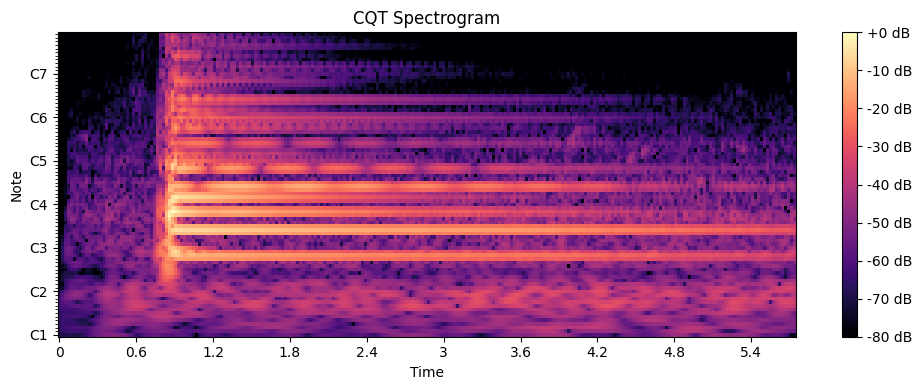

In [151]:
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import time

start = time.time()

sample = ds["train"][1]
audio = sample["audio"].get_all_samples()

waveform = audio.data.squeeze().cpu().numpy()   # make it 1D NumPy
sr = audio.sample_rate

C = librosa.cqt(
    y=waveform,
    sr=sr,
    hop_length=512,
    n_bins=84,
    bins_per_octave=12
)

C_db = librosa.amplitude_to_db(np.abs(C), ref=np.max)

end = time.time()
print(f"Time: {end - start:.2f} seconds")

plt.figure(figsize=(10, 4))
librosa.display.specshow(
    C_db,
    sr=sr,
    x_axis="time",
    y_axis="cqt_note",
    hop_length=512
)
plt.colorbar(format="%+2.0f dB")
plt.title("CQT Spectrogram")
plt.tight_layout()
plt.show()

In [153]:
start = time.time()
chroma = librosa.feature.chroma_cqt(y=waveform, sr=sr)
end = time.time()
print(f"Time: {end - start:.2f} seconds")

Time: 0.10 seconds


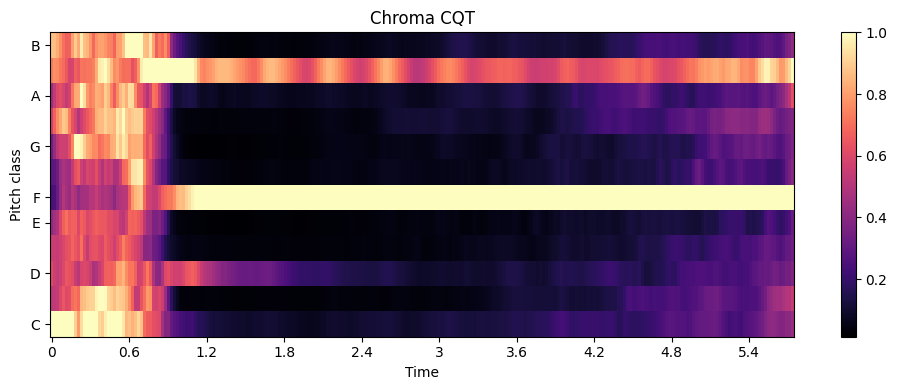

In [166]:
plt.figure(figsize=(10, 4))

librosa.display.specshow(
    chroma,
    x_axis="time",
    y_axis="chroma",
    sr=sr
)

plt.colorbar()
plt.title("Chroma CQT")
plt.tight_layout()
plt.show()

In [97]:
print(sample["label"])

1


### Visually check another Chord

3


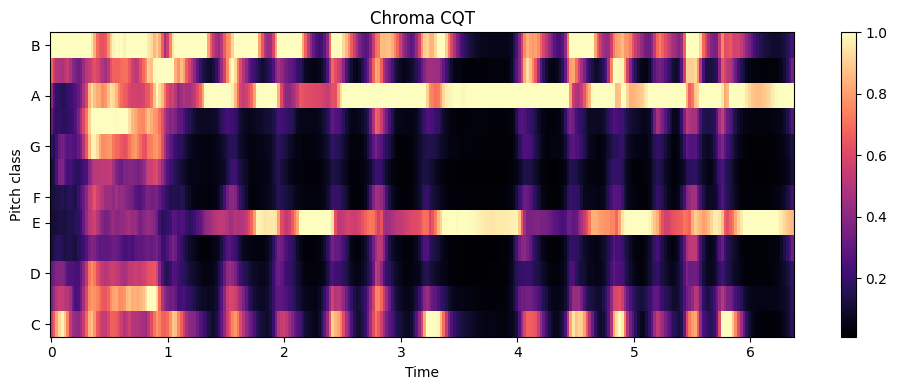

In [174]:
sample = ds["train"][100]
audio = sample["audio"].get_all_samples()

waveform = audio.data.squeeze().cpu().numpy()   # make it 1D NumPy
sr = audio.sample_rate

print(sample["label"])

chroma = librosa.feature.chroma_cqt(y=waveform, sr=sr)

plt.figure(figsize=(10, 4))

librosa.display.specshow(
    chroma,
    x_axis="time",
    y_axis="chroma",
    sr=sr
)

plt.colorbar()
plt.title("Chroma CQT")
plt.tight_layout()
plt.show()

This is the plot of Am. Clearly, the notes of A, E, and C are highlighted. However, chroma cqt does show some presence of B. Possible issue

## Conclusion

To start, best option seems  to be the Chroma CQT representation. It is lighter and better for smaller datasets